In [6]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from generalization_gap_utils import *
from trajectory_based_utils import overfit_vs_snaps, get_fds
from plot_utils import setup_plot

plt.style.use('default')

%load_ext autoreload
%autoreload 2

data_folder = '/home/shared/generative_models/diffusion_overfit/data'
figs_folder = '/home/tikai103/diffusion_overfit/plots'
save_figs = False

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Contents

### This notebook generates all plots for our reconstruction-based metrics, as well as Figure 1.
1. [Figure 1 plots](#1.-Figure-1-plots)
2. [Generalization gap vs training time (fixed sigma)](#2.-Generalization-gap-vs-training-time-\(fixed-sigma\))
3. [Generalization gap vs sigma](#3.-Generalization-gap-vs-sigma)
4. [Generalization gap for diffusion guidance](#4.-Generalization-gap-for-diffusion-guidance)
5. [Generalization gap for cluster granularity](#5.-Generalization-gap-for-cluster-granularity)
6. [Generalization gap for long-range correlations (restricted receptive field)](#6.-Generalization-gap-for-long-range-correlations-\(restricted-receptive-field\))

## 1. Figure 1 plots

in64 with edm2-m
Found 32 checkpoints: [67108, 134217, 201326, 268435, 335544, 402653, 469762, 536870, 603979, 671088, 738197, 805306, 872415, 939524, 1006632, 1073741, 1140850, 1207959, 1275068, 1342177, 1409286, 1476395, 1543503, 1610612, 1677721, 1744830, 1811939, 1879048, 1946157, 2013265, 2080374, 2147483]
Plotting for $\sigma = $ 2.0
1006632 0.043657377


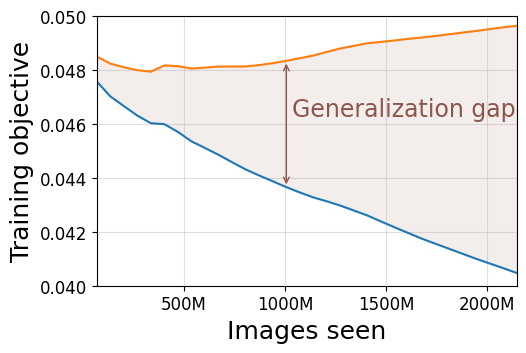

In [9]:
dataset = 'in64'  # todo: make this work for CIFAR-10, need metrics first.
model_size = 'm'
model = f'edm2-{model_size}'
print(f"{dataset} with {model}")

# First plot
plt.figure(figsize=(6,3.5))
plt.subplots_adjust(left=0.2)
s_idx, sigma_bins = gg_vs_snaps(dataset, model, overfit=False)
if save_figs:
    # plt.savefig(f'{figs_folder}/figs/icml2025/re-vs-Mimg_{dataset}-{model}_sigma_{sigma_bins[s_idx]:.2f}.png', dpi=200, bbox_inches='tight')
    plt.savefig(f'{figs_folder}/figs/eccv2026/gen_gap_illustration_{dataset}-{model}_sigma_{sigma_bins[s_idx]:.2f}.pdf', dpi=200, bbox_inches='tight')
plt.show()
plt.close()

Selecting sigma 1.67 for model Training objective.


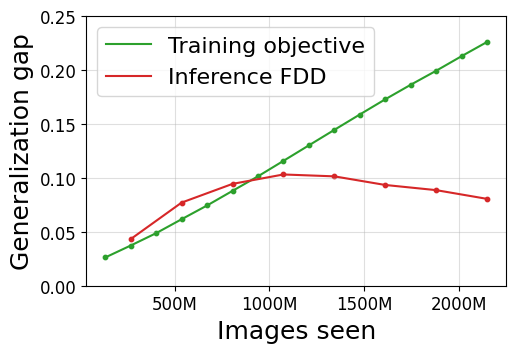

In [5]:
dataset = 'in64'  # 'in64', 'in512'
mode = 'overfit'  # 'train', 'val', 'train-val' or 'overfit'
early_stop = 18
models_data = {}
early_stops = [-1] # [16, 17, 18, 19, 20, -1]

for early_stop in early_stops:
    # Get fd-metrics and their snaps
    fd_data = get_fds(dataset, early_stop=early_stop)  # only for this model_size
    model_sizes = list(fd_data.keys())
    if dataset == 'in64':
        model_sizes = [s for s in model_sizes if 'xx' not in s]  # exclude xxs and xxl models on IN64, they don't exist
    for model_name in model_sizes:
            if 'm' not in model_name:
                continue
            models_data[f"{model_name}-stop{early_stop}" if early_stop != -1 else model_name] = fd_data[model_name]

for metric in ['FDD']:
    ##
    plt.figure(figsize=(6,3.5))
    plot_mode = 'overfit' 
    for metric in ['pl2']:
        for d, dataset in enumerate(['in64']):
            if dataset == 'in64':
                model_sizes = ['m']  # 'xs-uncond', 'xs', 's', 'm', 'l', 'xl'
                models = [f'edm2-{model_size}' for model_size in model_sizes]
                ylim = (-0.03, 0.25)
            elif dataset == 'in512':
                model_sizes = ['xxs', 'xs-uncond', 'xs', 's', 'm', 'l', 'xl', 'xxl']  # 'xxs-uncond', 
                models = [f"edm2-{model_size}" for model_size in model_sizes]
                ylim = (-0.03, 0.10)
            elif 'cifar' in dataset:
                models = ['edm']
                ylim = (-0.03, 0.35)
            for m, (model, model_size) in enumerate(zip(models, model_sizes)):
                # Get data paths
                tr_paths, val_paths = [], []
                no_data = False
                for mode, paths in [('train', tr_paths), ('val', val_paths)]:
                    data_folder = f'{data_folder}/loss_analysis/{dataset}/{model}/{mode}_data'
                    if not os.path.exists(data_folder):
                        no_data = True
                        print(data_folder)
                        break
                    for path in sorted([f'{data_folder}/{s}' for s in os.listdir(data_folder) if 'data' in s]):
                        paths.append(path)
        
                if len(tr_paths) == 0:
                    print(f"No paths for {model}, skipping...")
                    continue
                snaps = np.array([int(tr_paths[i].replace('-0.100', '').split('/')[-1].split('.')[0].split('-')[-1]) for i in range(len(tr_paths))])
                sigma_idx = sigma_ids[dataset][metric]['avg'] if 'in' in dataset else sigma_ids[dataset][metric]
                color = plt.cm.viridis(1 - m / len(models)) if 'in' in dataset else f'C{d}'
                gen_gap_vs_model_error(tr_paths, val_paths, snaps, sigma_idx, metric, 
                                       model_name='Training objective', 
                                       color='C2', 
                                       mode=plot_mode)
        
        # plt.ylabel(metric)
        if metric == 'rfdd' and plot_mode == 'train-val' and dataset == 'in64':
            plt.ylim(top=600)
        plt.legend()

    fontsize = 18
    plt.xticks([500000, 1000000, 1500000, 2000000], 
              ['500M', '1000M', '1500M', '2000M'], fontsize=fontsize-6)
    plt.yticks(fontsize=fontsize-6)
    metric = 'FDD'
    mode='overfit'
    ##
    
    overfit_vs_snaps(models_data, metric, mode=mode, x_axis='snaps', label='Inference FDD', c='C3')
    plt.ylim([0, 0.25])
    plt.legend(fontsize=fontsize-2, loc=2)
    plt.ylabel("Generalization gap", fontsize=fontsize)
    plt.xlabel("Images seen", fontsize=fontsize)
    plt.subplots_adjust(left=0.2)
    if save_figs:
        if len(early_stops) == 1 and early_stops[0] == -1:
            plt.savefig(f'{figs_folder}/figs/eccv2026/overfit_vs_snaps/overfit_vs_snaps-{mode}-{metric}-{dataset}.png', dpi=200, bbox_inches='tight')
        else:
            plt.savefig(f'{figs_folder}/figs/eccv2026/overfit_vs_snaps/overfit_vs_snaps-{mode}-{metric}-{dataset}-early_stop.png', dpi=200, bbox_inches='tight')
        # plt.savefig(f'{figs_folder}/figs/eccv2026/metrics_illustration_{dataset}-{model}.pdf', dpi=200, bbox_inches='tight')
    plt.show()
    plt.close()

## 2. Generalization gap vs training time (fixed sigma)

Metric: rfdd
Selecting sigma 1.41 for model xs-uncond.
Reducing number of points from 32 to 16 for model xs-uncond.
Selecting sigma 1.41 for model xs.
Reducing number of points from 32 to 16 for model xs.
Selecting sigma 1.41 for model s.
Selecting sigma 1.41 for model m.
Selecting sigma 1.41 for model l.
Selecting sigma 1.41 for model xl.


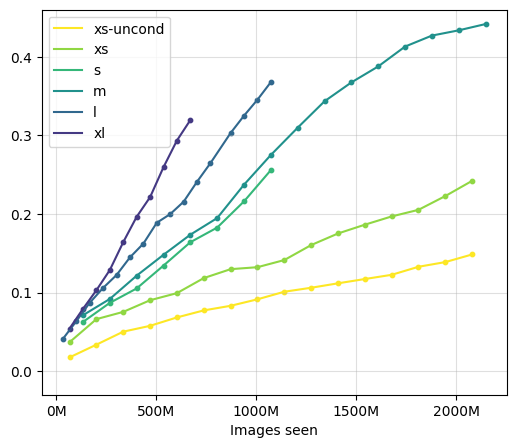

In [16]:
datasets = ['in64']  # in64, in612, cifar (includes 10 and 100)
plot_mode = 'overfit'  # 'overfit' or 'train-val'

for metric in ['rfdd']:  # 'pl2', 'dino-l2', 'incp-l2', 'rfdd', 'rfid'
    print(f"Metric: {metric}")
    plt.figure(figsize=(6,5))
    for d, dataset in enumerate(datasets):
        if dataset == 'in64':
            model_sizes = ['xs-uncond', 'xs', 's', 'm', 'l', 'xl']  # 'xs-uncond', 'xs', 's', 'm', 'l', 'xl'
            models = [f'edm2-{model_size}' for model_size in model_sizes]
            ylim = (-0.03, 0.25)
        elif dataset == 'in512':
            model_sizes = ['xxs', 'xs-uncond', 'xs', 's', 'm', 'l', 'xl', 'xxl']  # 'xxs-uncond', 
            models = [f"edm2-{model_size}" for model_size in model_sizes]
            ylim = (-0.03, 0.10)
        elif 'cifar' in dataset:
            models = ['edm']
            ylim = (-0.03, 0.35)
        for m, (model, model_size) in enumerate(zip(models, model_sizes)):
            # Get data paths
            tr_paths, val_paths = [], []
            no_data = False
            for mode, paths in [('train', tr_paths), ('val', val_paths)]:
                data_folder = f'{data_folder}/loss_analysis/{dataset}/{model}/{mode}_data'
                if not os.path.exists(data_folder):
                    no_data = True
                    print(data_folder)
                    break
                for path in sorted([f'{data_folder}/{s}' for s in os.listdir(data_folder) if 'data' in s]):
                    paths.append(path)
    
            if len(tr_paths) == 0:
                print(f"No paths for {model}, skipping...")
                continue
            snaps = np.array([int(tr_paths[i].replace('-0.100', '').split('/')[-1].split('.')[0].split('-')[-1]) for i in range(len(tr_paths))])
            sigma_idx = sigma_ids[dataset][metric]['avg'] if 'in' in dataset else sigma_ids[dataset][metric]
            color = plt.cm.viridis(1 - m / len(models)) if 'in' in dataset else f'C{d}'
            gen_gap_vs_model_error(tr_paths, val_paths, snaps, sigma_idx, metric, 
                                   model_name=model_size if 'in' in dataset else dataset, 
                                   color=color, 
                                   mode=plot_mode)
    
    # plt.ylabel(metric)
    if metric == 'rfdd' and plot_mode == 'train-val' and dataset == 'in64':
        plt.ylim(top=600)
    if dataset == 'in64' and metric == 'rfdd':
        if plot_mode == 'overfit':
            plt.ylim([-0.03, 0.46])
        else:
            plt.ylim([40,600])
        
    plt.legend()
    setup_plot()

    if save_figs:
        plt.savefig(f'{figs_folder}/figs/eccv2026/gen_gaps_vs_model_error/{metric}-gap-vs-model_error-{dataset}-{plot_mode}.png', dpi=200, bbox_inches='tight')
    plt.show()
    plt.close()

## 3. Generalization gap vs sigma

In [ ]:
datasets = ['in64']  # in64, in612, cifar10, cifar100, ffhq

for metric in ['pl2']:  # 'pl2', 'incp-l2', 'dino-l2', 'rfid', 'rfdd'
    print(f"Metric: {metric}")
    sigmas = []
    for i, dataset in enumerate(datasets):
        if dataset == 'in64':
            model_sizes = ['xl']  # 'xs-uncond', 'xs', 's', 'm', 'l', 'xl'
            models = [f'edm2-{model_size}' for model_size in model_sizes]
            ylim = (-0.03, 0.25)
        elif dataset == 'in512':
            model_sizes = ['s']  # 'xxs-uncond', 'xs-uncond', 'xxs', 'xs', 's', 'm', 'l', 'xl', 'xxl'
            models = [f"edm2-{model_size}" for model_size in model_sizes]
            ylim = (-0.03, 0.30)
        elif 'cifar' in dataset:
            model_sizes = [None]
            models = ['edm']
            ylim = (-0.12, 0.35)
        for j, (model, model_size) in enumerate(zip(models, model_sizes)):
            # print(model)
            plt.figure(figsize=(6,5))
    
            # Get data paths
            tr_paths, val_paths = [], []
            no_data = False
            for mode, paths in [('train', tr_paths), ('val', val_paths)]:
                data_folder = f'{data_folder}/loss_analysis/{dataset}/{model}/{mode}_data'
                if not os.path.exists(data_folder):
                    no_data = True
                    print(data_folder)
                    break
                for path in sorted([f'{data_folder}/{s}' for s in os.listdir(data_folder) if 'data' in s]):
                    paths.append(path)
    
            # Set total range for colors
            color_range = np.array([int(tr_paths[i].replace('-0.100', '').split('/')[-1].split('.')[0].split('-')[-1]) for i in range(len(tr_paths))])
            rel_error, tr_eps, val_eps, sigma_bins = gen_gap_vs_sigma(tr_paths, val_paths, color_range, x_formatter=True, ylim=ylim, metric=metric)
    
            # Compute overfit threshold
            th_idx = val_eps.argmin(axis=0)  # Assuming that the validation error is always convex
            arange = np.arange(th_idx.shape[0])
            th_value = (val_eps[th_idx, arange] - tr_eps[th_idx, arange]) / tr_eps[th_idx, arange]
            # plt.title(model)
            plt.plot(sigma_bins, th_value, linestyle='-', color='black', label='overfit', linewidth=2)
            plt.legend()

            # Add sigma-line at peak
            sigma_idx = np.argmax(rel_error[-1]).item()
            sigmas.append(sigma_idx)
            plt.axvline(sigma_bins[sigma_idx], color='black', linestyle=':')
            # print(f"sigma: {sigma_bins[sigma_idx]:.3f}")
            
            if save_figs:
                plt.savefig(f'{figs_folder}/figs/eccv2026/gen_gaps_vs_sigma/{metric}-gap-{dataset}-{model}.png', dpi=200, bbox_inches='tight')
            plt.show()
            plt.close()
        print(sigmas)

## 4. Generalization gap for diffusion guidance

auto pl2
Selecting sigma 1.67 for model pl2.
Reducing number of points from 20 to 10 for model pl2.
auto dino-l2
Selecting sigma 1.19 for model dino-l2.
Reducing number of points from 20 to 10 for model dino-l2.
auto rfdd
Selecting sigma 1.19 for model rfdd.
Reducing number of points from 20 to 10 for model rfdd.
Didn't find data for xxs-uncond, skipping...
Didn't find data for xxs, skipping...
Didn't find data for xs-uncond, skipping...
Didn't find data for xs, skipping...
Didn't find data for m, skipping...
Didn't find data for l, skipping...
Didn't find data for xl, skipping...
Didn't find data for xxl, skipping...


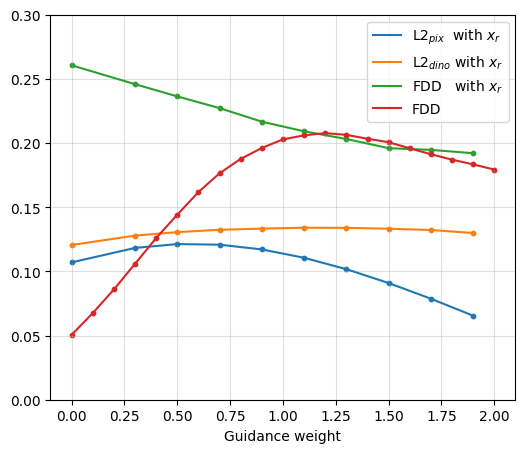

regular pl2
Selecting sigma 1.67 for model pl2.
regular dino-l2
Selecting sigma 1.19 for model dino-l2.
regular rfdd
Selecting sigma 1.19 for model rfdd.
Didn't find data for xxs-uncond, skipping...
Didn't find data for xxs, skipping...
Didn't find data for xs-uncond, skipping...
Didn't find data for xs, skipping...
Didn't find data for m, skipping...
Didn't find data for l, skipping...
Didn't find data for xl, skipping...
Didn't find data for xxl, skipping...


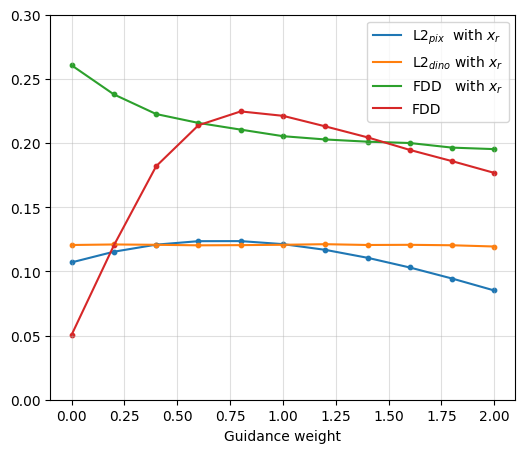

In [8]:
plot_type = 'model_error'  # 'model_error' or 'sigma'
plot_mode = 'overfit'  # 'overfit' or 'train-val'

datasets = ['in64']  # in64, in612, cifar10, cifar100, ffhq
metric = 'pl2' # 'pl2' or 'incp-l2' 'dino-l2' or 'rfid' or 'rfdd'
snap = '1073741'  # fixed snap
f_extractor = 'dino'  # 'incp' or 'dino'
guidance_modes = ['auto', 'regular']

if f_extractor == 'incp':
    metrics = ['pl2', 'incp-l2', 'rfid']  # ['pl2', 'incp-l2', 'rfid']
    labels = ['L2$_{pix}$  with $x_r$', 'L2$_{incp}$ with $x_r$', 'FDD   with $x_r$']
    colors = ['C0', 'C1', 'C2']
    linestyles = ['-', '-', '-']
    sigma_ids = [40, 37, 41]  # hand-picked based on the 'sigma' plot
elif f_extractor == 'dino':
    metrics = ['pl2', 'dino-l2', 'rfdd']
    labels = ['L2$_{pix}$  with $x_r$', 'L2$_{dino}$ with $x_r$', 'FDD   with $x_r$']
    colors = ['C0', 'C1', 'C2']
    linestyles = ['-', '-', '-']
    sigma_ids = [40, 38, 38]  # hand-picked based on the 'sigma' plot

for guidance_mode in guidance_modes:  # 'auto' or 'cfg'
    if plot_type == 'model_error':
        plt.figure(figsize=(6,5))

    for m, (metric, sigma_idx, label, color, linestyle) in enumerate(zip(metrics, sigma_ids, labels, colors, linestyles)):
        print(f"Guidnace mode: {guidance_mode}, Metric: {metric}")
        for i, dataset in enumerate(datasets):
            if dataset == 'in64':
                models = ['edm2-s']
            elif dataset == 'in512':
                models = ['edm2-xs', 'edm2-xxl']
            elif dataset == 'cifar10':
                models = ['edm']
            for j, model in enumerate(models):
                if plot_type == 'sigma':
                    plt.figure(figsize=(6,5))
        
                # Get data paths
                tr_paths, val_paths = [], []
                no_data = False
                cur_snap = None
                for mode, paths in [('train', tr_paths), ('val', val_paths)]:
                    parent_folder = f'{data_folder}/loss_analysis/{dataset}/{guidance_mode}'
                    subfolders = next(os.walk(parent_folder))[1]
                    for subfolder in subfolders:
                        data_folder = os.path.join(parent_folder, subfolder, f'{mode}_data')
                        if model not in data_folder or 'swg' in data_folder:
                            continue
    
                        if not os.path.exists(data_folder):
                            no_data = True
                            print(f"Found no data for {model}.")
                            break
    
                        path = f'{data_folder}/{sorted(os.listdir(data_folder))[-1]}'
                        paths.append(path)
                        next_snap = path.split('-')[-2]
                        if cur_snap is None:
                            cur_snap = next_snap
                        else:
                            assert cur_snap == next_snap, f"Snaps don't match. Previous: {cur_snap}. Next: {next_snap}."
    
                # Set total range for colors
                color_range = np.array([float(tr_paths[i].split('/')[-3].split('-w')[-1]) if '-w' in tr_paths[i] else 0.0 for i in range(len(tr_paths))])
    
                # Generalization gap across sigmas
                if plot_type == 'sigma':
                    rel_error, tr_eps, val_eps, sigma_bins = gen_gap_vs_sigma(tr_paths, val_paths, color_range, x_formatter=False, ylim=None, metric=metric)
                    plt.axvline(sigma_bins[sigma_idx], color='black', linestyle=':')
                    plt.ylim(bottom=-0.01)
                    if save_figs:
                        plt.savefig(f'{figs_folder}/figs/eccv2026/gen_gaps_vs_sigma/{metric}-gap-{dataset}-{model}-{guidance_mode}.png', dpi=200, bbox_inches='tight')
                    plt.show()
                    plt.close()
                    
                # Generalization gap vs model error
                if plot_type == 'model_error':
                    gen_gap_vs_model_error(tr_paths, val_paths, color_range, sigma_idx, metric, metric, color=color, mode=plot_mode, label=label, linestyle=linestyle)
    
    if plot_type == 'model_error':
        metric = 'FDD' if f_extractor == 'dino' else 'FID'
       
        # Load FDD results
        fd_data = get_fds(f"{dataset}_{guidance_mode}")  # only for this model_size
        overfit_vs_snaps(fd_data, metric, mode=plot_mode, x_axis='weights', x_key='weights', c='C3')

        plt.legend()
        setup_plot(xlabel='Guidance weight', snaps_on_x=False)
        if plot_mode == 'overfit':
            plt.ylim([0.0, 0.3] if f_extractor == 'dino' else [0.0, 0.4])
        else:
            # plt.ylim([0.0, 0.3] if f_extractor == 'dino' else [0.0, 0.4])
            plt.yscale('log')
        if save_figs:
            plt.savefig(f'{figs_folder}/figs/eccv2026/gen_gaps_vs_model_error/gap-{dataset}-{model}-{guidance_mode}-{f_extractor}-{plot_mode}.png', dpi=200, bbox_inches='tight')
        plt.show()
        plt.close()

## 5. Generalization gap for cluster granularity

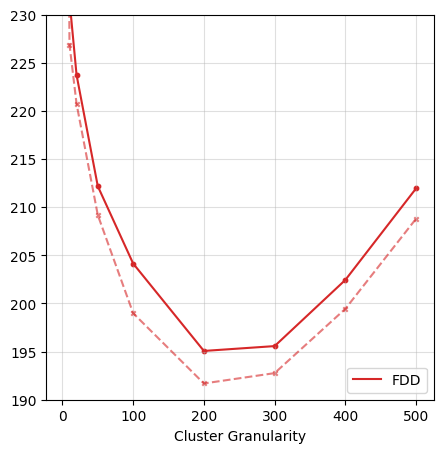

In [25]:
plot_type = 'model_error'  # 'model_error' or 'sigma'
plot_mode = 'train-val'  # 'overfit' or 'train-val'
datasets = ['cifar10']  # cifar10, cifar100
model = 'edm'
snap = '1073741'  # fixed snap
f_extractor = 'dino'  # 'incp' or 'dino'

# for model error plot
if f_extractor == 'incp':
    metrics = ['pl2', 'incp-l2', 'rfid'] if plot_mode == 'overfit' else []  # ['pl2', 'incp-l2', 'rfid']
    labels = ['L2$_{pix}$  with $x_r$', 'L2$_{incp}$ with $x_r$', 'FDD   with $x_r$']
    colors = ['C0', 'C1', 'C2']
    linestyles = ['-', '-', '-']
    sigma_ids = [39, 37, 41]  # hand-picked based on the 'sigma' plot
elif f_extractor == 'dino':
    metrics = ['pl2', 'dino-l2', 'rfdd'] if plot_mode == 'overfit' else []
    labels = ['L2$_{pix}$  with $x_r$', 'L2$_{dino}$ with $x_r$', 'FDD   with $x_r$']
    colors = ['C0', 'C1', 'C2']
    linestyles = ['-', '-', '-']
    sigma_ids = [39, 39, 39]  # hand-picked based on the 'sigma' plot
    
if plot_type == 'model_error':
    plt.figure(figsize=(5,5))

# Get data paths
tr_paths, val_paths = [], []
no_data = False
cur_snap = None
for i, dataset in enumerate(datasets):
    if plot_type == 'sigma':
        plt.figure(figsize=(6,5))

    for mode, paths in [('train', tr_paths), ('val', val_paths)]:
        parent_folder = f'{data_folder}/loss_analysis/{dataset}'
        subfolders = next(os.walk(parent_folder))[1]
        for subfolder in subfolders:
            data_folder = os.path.join(parent_folder, subfolder, f'{mode}_data')
            if 'kmeans' not in data_folder:
                continue
    
            if not os.path.exists(data_folder):
                no_data = True
                print(f"Found no data for {model}.")
                break
    
            path = f'{data_folder}/{sorted(os.listdir(data_folder))[-1]}'  # Last snap
            paths.append(path)
            next_snap = path.split('-')[-2]
            if cur_snap is None:
                cur_snap = next_snap
            else:
                assert cur_snap == next_snap, f"Snaps don't match. Previous: {cur_snap}. Next: {next_snap}."
            # print(f'{data_folder}/{sorted(os.listdir(data_folder))[-1]}')
    
    for m, (metric, sigma_idx, label, color, linestyle) in enumerate(zip(metrics, sigma_ids, labels, colors, linestyles)):
        print(f"Metric: {metric}")
        # Set total range for colors
        color_range = np.array([int(tr_paths[i].split('/')[8].split('-')[-1]) for i in range(len(tr_paths))])

        # Generalization gap across sigmas
        if plot_type == 'sigma':
            rel_error, tr_eps, val_eps, sigma_bins = gen_gap_vs_sigma(tr_paths, val_paths, color_range, x_formatter=False, ylim=None, metric=metric)
            plt.axvline(sigma_bins[sigma_idx], color='black', linestyle=':')
            if save_figs:
                plt.savefig(f'{figs_folder}/figs/eccv2026/gen_gaps_vs_sigma/{metric}-gap-{dataset}-{model}-kmeans.png', dpi=200, bbox_inches='tight')
            plt.show()
            plt.close()
            
        # Generalization gap vs model error
        if plot_type == 'model_error':
            # pass
            gen_gap_vs_model_error(tr_paths, val_paths, color_range, sigma_idx, metric, metric, color=color, mode=plot_mode, label=label, linestyle=linestyle)

if plot_type == 'model_error':
    # Load FD results
    fd_data = {'cifar10': get_fds(f"{dataset}_kmeans")}  # only for this model_size
    overfit_vs_snaps(fd_data, 'FDD' if f_extractor == 'dino' else 'FID', mode=plot_mode, x_axis='kmeans', x_key='kmeans')

    setup_plot(xlabel='Cluster Granularity', snaps_on_x=False)
    if plot_mode == 'overfit':
        plt.ylim([-0.04, 0.1] if f_extractor == 'dino' else [0.0, 0.1])
    else:
        plt.ylim([190, 230] if f_extractor == 'dino' else [4, 6])
    plt.legend(loc=4)
    if save_figs:
        plt.savefig(f'{figs_folder}/figs/eccv2026/gen_gaps_vs_model_error/gap-{dataset}-{model}-kmeans-{f_extractor}-{plot_mode}.png', dpi=200, bbox_inches='tight')
    plt.show()
    plt.close()

Loaded 11 training and 11 validation paths for models.


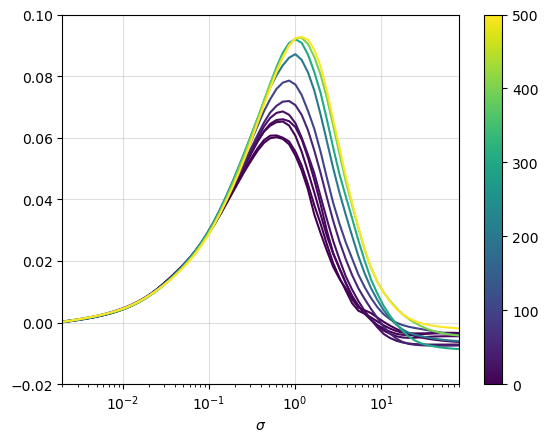

In [11]:
def load_model_paths(dataset, models, checkpoint='network-snapshot-100000.pkl'):
    """Collect the path for the specified checkpoint for each model."""
    tr_paths, val_paths = [], []

    # Iterate over all models and load matching data paths
    for model in models:
        for mode in ['train', 'val']:
            data_folder = f'{data_folder}/loss_analysis/{dataset}/{model}/{mode}_data'
            for path in sorted([f'{data_folder}/{s}' for s in os.listdir(data_folder) if 'data' in s]):
                if checkpoint == int(path.replace('-0.100', '').split('.')[0].split('-')[-1]) // 1000 * 1000:
                    (tr_paths if mode == 'train' else val_paths).append(path)

    return tr_paths, val_paths


dataset = 'cifar10'
models = [
    'edm-uncond',
    'edm-kmeans-2',
    'edm-kmeans-5',
    'edm-kmeans-10',
    'edm-kmeans-20',
    'edm-kmeans-50',
    'edm-kmeans-100',
    'edm-kmeans-200',
    'edm-kmeans-300',
    'edm-kmeans-400',
    'edm-kmeans-500',
]

# Load training and validation data paths
checkpoint_name = 100000
tr_paths, val_paths = load_model_paths(dataset, models, checkpoint=checkpoint_name)

assert len(tr_paths) == len(models), f"len(tr_paths) ({len(tr_paths)}) != len(models) ({len(models)})."
assert len(val_paths) == len(models), f"len(val_paths) ({len(val_paths)}) != len(models) ({len(models)})."

print(f"Loaded {len(tr_paths)} training and {len(val_paths)} validation paths for models.")

cluster_granularity = []
for m in models:
    if 'uncond' in m:
        cluster_granularity.append(0)
    elif m == 'edm':
        cluster_granularity.append(10)
    else:
        cluster_granularity.append(float(m.split('-')[-1]))

rel_errors, train_residuals, val_residuals, sigma_bins = gen_gap_vs_sigma(tr_paths, val_paths, color_range=cluster_granularity, ylim=[-0.02, 0.1], x_formatter=False)
if save_figs:
    plt.savefig(f'{figs_folder}/figs/icml2025/residual-overfit-pseudo_labels-{dataset}.png', dpi=200, bbox_inches='tight')

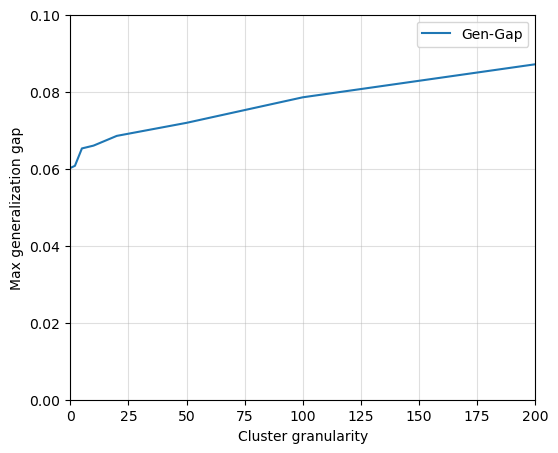

In [13]:
# Run the cell above first
# Plot the progression of the peak of the generalization gap for incrasing cluster granularity

max_gen_gap = rel_errors.max(axis=1)
assert max_gen_gap.shape == (len(models),), f"max_gen_gap.shape ({max_gen_gap.shape}) != ({len(models)},)"

# fids = [...]  # todo
# fdds = [...]  # todo

plt.figure(figsize=(6,5))
plt.plot(cluster_granularity, max_gen_gap, label='Gen-Gap')
# plt.plot(cluster_granularity, fids, label='FID')
# plt.plot(cluster_granularity, fdds, label='FDD')

plt.grid(alpha=0.4)
plt.xlim([0,200])
plt.ylim([0,0.1])
plt.legend()
plt.xlabel('Cluster granularity')
plt.ylabel('Max generalization gap')
plt.show()

## 6. Generalization gap for long-range correlations (restricted receptive field)

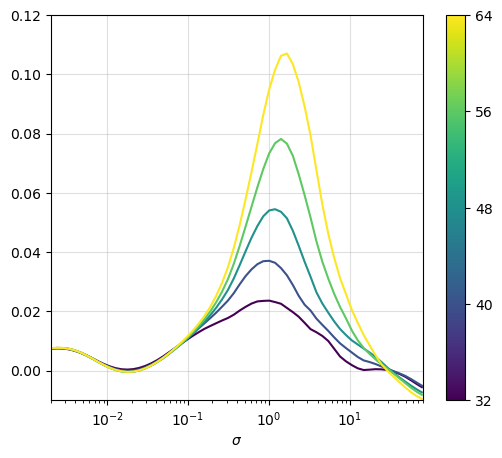

In [12]:
sigma_min, sigma_max = 2e-3, 80

datasets = ['in64']

for i, dataset in enumerate(datasets):
    if dataset == 'in64':
        models = ['edm2-s']
    elif dataset == 'in512':
        models = ['edm2-xxl']
    elif dataset == 'cifar10':
        models = ['edm']
    for j, model in enumerate(models):
        if i == 0 and j == 0:
            plt.figure(figsize=(6*len(models),5*len(datasets)))
        plt.subplot(len(datasets),len(models),len(datasets)*i+j+1)

        # Get data paths
        tr_paths, val_paths = [], []
        for mode, paths in [('train', tr_paths), ('val', val_paths)]:
            data_folder = f'{data_folder}/loss_analysis/{dataset}'
            for path in sorted([f'{data_folder}/{s}' for s in os.listdir(data_folder) if f'{model}-swg' in s]):
                data_path = f"{path}/{mode}_data/"
                files = sorted(os.listdir(data_path))
                paths.append(os.path.join(data_path, files[-1]))  # Take longest checkpoint

            # Manually add the baseline
            path = f'{data_folder}/{model}'
            data_path = f"{path}/{mode}_data/"
            files = sorted(os.listdir(data_path))
            paths.append(os.path.join(data_path, files[-1]))  # Take longest checkpoint

        # Set total range for colors
        color_range = np.array([float(path.split('/')[-3].split('-swg')[-1]) for path in tr_paths[:-1]])  # Exclude last
        color_range = np.append(color_range, 64 if 'in' in dataset else 32)

        ylim = [-0.02, 0.1] if dataset == 'in512' else [-0.01, 0.12]
        gen_gap_vs_sigma(tr_paths, val_paths, color_range, x_formatter=False, ylim=ylim, cbar_ticks=color_range)
        
        if save_figs:
            plt.savefig(f'{figs_folder}/figs/eccv2026/gen_gaps_vs_sigma/l2-overfit-swg-{dataset}-{model}.png', dpi=200, bbox_inches='tight')

# Sandbox

## Conditional vs unconditional generation

(0.267004, 0.004874, 0.329415, 1.0) (0.127568, 0.566949, 0.550556, 1.0) (0.974417, 0.90359, 0.130215, 1.0) (0.993248, 0.906157, 0.143936, 1.0)


IndexError: index 1 is out of bounds for axis 0 with size 1

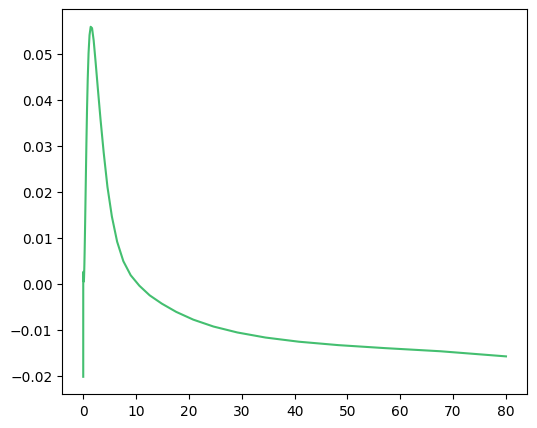

In [17]:
from matplotlib import colormaps


sigma_min, sigma_max = 2e-3, 80

datasets = ['in512']

for i, dataset in enumerate(datasets):
    if dataset == 'in64':
        models = ...  # todo
    elif dataset == 'in512':
        models = ['edm2-s']
    elif dataset == 'cifar10':
        models = ...  # todo

    # Get data paths
    tr_paths, val_paths = [], []
    for mode, paths in [('train', tr_paths), ('val', val_paths)]:
        data_folder = f'{data_folder}/loss_analysis/{dataset}'
        for model in models:
            for path in sorted([f'{data_folder}/{s}' for s in os.listdir(data_folder) if f'{model}' in s]):
                data_path = f"{path}/{mode}_data/"
                files = sorted(os.listdir(data_path))
                paths.append(os.path.join(data_path, files[-1]))  # Take longest checkpoint

    color_range = np.array([0,1])

    rel_error, tr_eps, val_eps, sigma_bins = gen_gap_vs_sigma(tr_paths, val_paths, color_range, x_formatter=False, ylim=[-0.02, 0.1], cbar_ticks=color_range);
    plt.close()

viridis = colormaps['viridis']
print(viridis(0), viridis(0.5), viridis(0.99), viridis(1.0))

plt.figure(figsize=(6,5))
plt.plot(sigma_bins, rel_error[0], label='Cond', color=viridis(0.7))
plt.plot(sigma_bins, rel_error[1], label='Uncond', color=viridis(0.0))
plot_layout(sigma_bins[0], sigma_bins[-1], scale_y=False, legend=True)
plt.xlabel('$\sigma$')
plt.ylim([-0.02, 0.1])
if save_figs:
    plt.savefig(f'{figs_folder}/figs/icml2025/residual-overfit-cond_vs_uncond-in512-xxl.png', dpi=200, bbox_inches='tight')

# Error vs sigma with EMA

In [3]:

sigma_min, sigma_max = 2e-3, 80
num_steps = 18
rho = 7

# Time step discretization.
step_indices = torch.arange(num_steps)
t_steps = (sigma_max ** (1 / rho) + step_indices / (num_steps - 1) * (sigma_min ** (1 / rho) - sigma_max ** (1 / rho))) ** rho
t_steps > 2e-1


tensor([ True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True, False, False, False, False, False])

In [ ]:
sigma_min, sigma_max = 2e-3, 80

datasets = ['in64', 'in512']
# datasets = ['cifar10']

# color_range = [67108, 134217, 201326, 268435, 335544, 402653, 469762, 536870, 603979, 
#                671088, 738197, 805306, 872415, 939524, 1006632, 1073741, 1140850, 1207959,
#                1275068, 1342177, 1409286, 1476395, 1543503, 1610612, 1677721, 1744830, 1811939,
#                1879048, 1946157, 2013265, 2080374, 2147483]  # max color range (IN512, XS)

snap = '0671088'  # Snap that was used for this experiment across all models

for i, dataset in enumerate(datasets):
    if dataset == 'in64':
        models = ['edm2-s', 'edm2-xl']
    elif dataset == 'in512':
        models = ['edm2-xs', 'edm2-xxl']
    elif dataset == 'cifar10':
        models = ['edm']
    for j, model in enumerate(models):
        if i == 0 and j == 0:
            plt.figure(figsize=(6*len(models),5*len(datasets)))
        plt.subplot(len(datasets),len(models),len(datasets)*i+j+1)

        # Get data paths
        tr_paths, val_paths = [], []
        for mode, paths in [('train', tr_paths), ('val', val_paths)]:
            data_folder = f'{data_folder}/loss_analysis/{dataset}/{model}/{mode}_data'
            for path in sorted([f'{data_folder}/{s}' for s in os.listdir(data_folder) if f'data-{snap}-' in s]):
                paths.append(path)

        # Set total range for colors
        color_range = np.array([float(tr_paths[i].split('/')[-1].split('-')[-1].replace('.pt', '')) for i in range(len(tr_paths))])
        
        gen_gap_vs_sigma(tr_paths, val_paths, color_range, x_formatter=False, ylim=[-0.05, 0.16])

if save_figs:
    plt.savefig(f'{figs_folder}/figs/icml2025/residual-overfit-in512-xxl.png', dpi=200, bbox_inches='tight')

# Std analysis at sigma=2, EDM2-XS

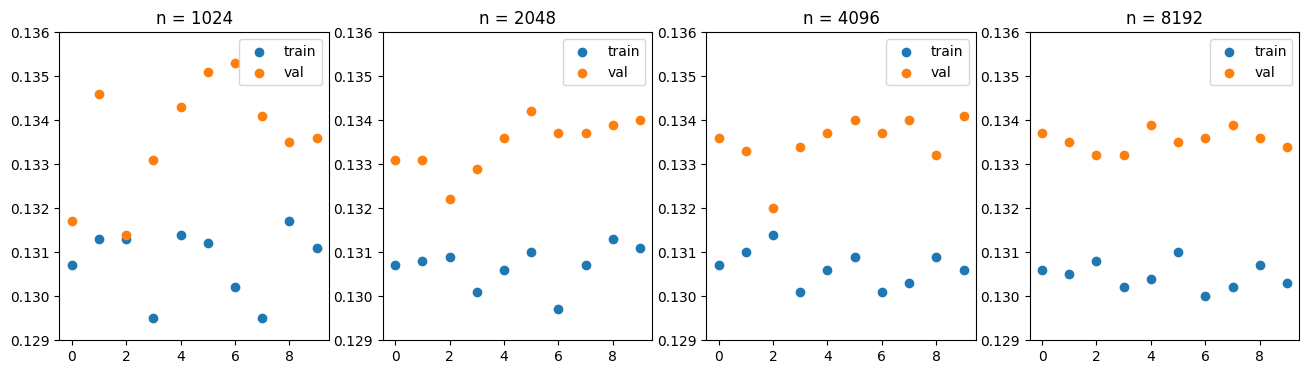

In [112]:
tr = {}
val = {}

# 1024
tr[1024] = np.array([1.307, 1.313, 1.313, 1.295, 1.314, 1.312, 1.302, 1.295, 1.317, 1.311]) * 1e-1
val[1024] = np.array([1.317, 1.346, 1.314, 1.331, 1.343, 1.351, 1.353, 1.341, 1.335, 1.336]) * 1e-1

# 2048
tr[2048] = np.array([1.307, 1.308, 1.309, 1.301, 1.306, 1.310, 1.297, 1.307, 1.313, 1.311]) * 1e-1
val[2048] = np.array([1.331, 1.331, 1.322, 1.329, 1.336, 1.342, 1.337, 1.337, 1.339, 1.340]) * 1e-1

# 4096
tr[4096] = np.array([1.307, 1.31, 1.314, 1.301, 1.306, 1.309, 1.301, 1.303, 1.309, 1.306]) * 1e-1
val[4096] = np.array([1.336, 1.333, 1.320, 1.334, 1.337, 1.340, 1.337, 1.340, 1.332, 1.341]) * 1e-1

# 8192
tr[8192] = np.array([1.306, 1.305, 1.308, 1.302, 1.304, 1.31, 1.30, 1.302, 1.307, 1.303]) * 1e-1
val[8192] = np.array([1.337, 1.335, 1.332, 1.332, 1.339, 1.335, 1.336, 1.339, 1.336, 1.334]) * 1e-1

x = np.arange(10)
plt.figure(figsize=(16,4))
for i, n in enumerate([1024, 2048, 4096, 8192]):
    plt.subplot(1,4,i+1)
    plt.scatter(x, tr[n], label='train')
    plt.scatter(x, val[n], label='val')
    plt.legend()
    plt.ylim([0.129, 0.136])
    plt.title(f"n = {n}")
    
    # plt.subplot(1,2,2)
    # plt.scatter(x, (val[n] - tr[n]) / tr[n], label='(val - tr) / tr')
    # plt.legend()


In [117]:
def edm_eff_weight(mu, var, sigma_data=0.5):
    # mu=-0.4, var=1.0: eff_mean = 6.88029
    sigma_min, sigma_max = 2e-3, 1e2
    num_steps = 10000
    start = float(np.log(sigma_min) / np.log(10))  # log(sigma_min) base 10
    end = float(np.log(sigma_max) / np.log(10))  # log(sigma_max) base 10
    sigma = np.logspace(start, end, num_steps)  # [num_steps]
    
    p_log_sigma = np.exp(((np.log(sigma) - mu)) ** 2 / var / -2) / (sigma * (var * 2 * np.pi) ** 0.5)  # N(log(sigma)) / sigma
    weight = (sigma**2 + sigma_data ** 2) / (sigma * sigma_data)**2
    eff_weight = p_log_sigma * sigma ** 1 * weight
    
    eff_mean = ((eff_weight[1:] + eff_weight[:-1])/2 * (sigma[1:] - sigma[:-1])).sum()
    eff_median = np.median(eff_weight)
    eff_median = sigma[np.abs(sigma - eff_median).argmin()]
    # eff_mean = sigma[eff_weight.argmax()]
    
    return sigma, weight, p_log_sigma, eff_weight, eff_mean

9.285885299975023
22.85024076403791
10.237793634844948


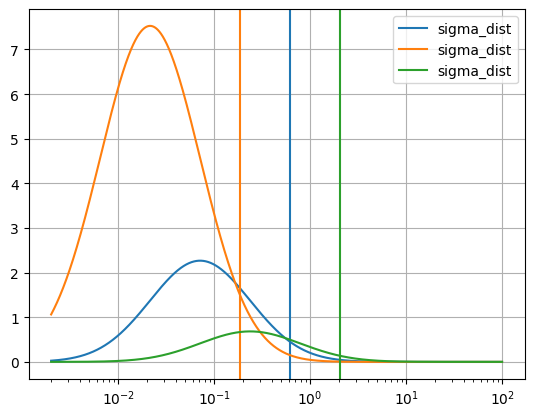

In [118]:
for i, (mu, var) in enumerate([(-1.2, 1.2**2), (-2.4, 1.2**2), (0, 1.2**2)]):
    print(edm_eff_weight(mu, var)[-1])
    
    sigma, weight, p_log_sigma, eff_weight, eff_mean = edm_eff_weight(mu, var)
    plt.plot(sigma, p_log_sigma, label='sigma_dist')
    # plt.plot(sigma, weight, label='weight')
    # plt.plot(sigma, eff_weight, label='eff weight')
    # plt.axvline(eff_mean, color='black', linestyle='--')
    plt.axvline(np.exp(mu + var / 2), color=f'C{i}')
    
    plt.xscale('log')
    # plt.ylim([0, 50])
    plt.grid()
    plt.legend()
    
    np.exp(mu - var), np.exp(mu + var / 2)

In [ ]:
# plot_3d()

In [7]:
sigma_min, sigma_max = 1e-3, 90

In [ ]:
resume_dir = "/home/shared/generative_models/inductive_bias/ours/cifar10/training/s-eps5e-2_g6-s1"
snaps = sorted([s for s in os.listdir(resume_dir) if 'network-snapshot' in s])[1:][::2][:-5]


n_bins = 128
start = float(torch.log(torch.tensor([1e-3])) / torch.log(torch.tensor([10])))  # log(sigma_min) base 10
end = float(torch.log(torch.tensor([90])) / torch.log(torch.tensor([10])))  # log(sigma_max) base 10
sigma_bins = torch.logspace(start, end, n_bins)

for snap in snaps[1:]:
    eff_weight = torch.load(f"/home/shared/generative_models/inductive_bias/ours/cifar10/training/s-eps5e-2_g6-s1_efficient/eff_weight_{snap}.pt").cpu().numpy()
    y = eff_weight / eff_weight.sum()
    plt.plot(sigma_bins, y, label=snap.split('.')[0].split('-')[-1])
    del eff_weight
    
plt.legend()
plot_layout(scale_y=False, legend=False)
plt.show()


# for snap in snaps:
#     rel_error = torch.load(f"/home/shared/generative_models/inductive_bias/ours/cifar10/training/s-eps5e-2_g6-s1_efficient/rel_error_{snap}.pt").cpu().numpy()
#     plt.plot(sigma_bins, rel_error.mean(axis=1), label=snap.split('.')[0].split('-')[-1])
#     del rel_error
    
# plt.legend()
# plot_layout(scale_y=False, legend=False)
# plt.show()